# Gaussian MC Baseline — Risk-Neutral Portfolio Optimization
## Phase 2: Baseline Model

This notebook implements the **risk-neutral Gaussian Monte Carlo baseline** described in Section 2.2.3 of the proposal. It is intentionally self-contained: it re-runs the data pipeline from `Data_Collection_Market_Shocks.ipynb` so it can be executed independently, then builds and evaluates the optimized baseline portfolio.

### What this notebook does
1. **Data pipeline** — re-fetches prices, computes log-returns, labels VIX regimes, and applies the 80/20 temporal split (identical to the EDA notebook).
2. **Gaussian fit** — fits μ̂ and Σ̂ (Ledoit–Wolf shrinkage) to the training data.
3. **MC scenario generation** — draws S=10,000 samples from N(μ̂, Σ̂).
4. **SLSQP optimization** — minimizes expected portfolio loss subject to the simplex constraint (long-only, fully invested).
5. **Efficient frontier** — sweeps a return target grid to produce the full mean-variance frontier.
6. **OOD COVID holdout** — evaluates performance on the Feb–May 2020 crash window the model was trained on (to be contrasted with the flow's OOD experiment later).
7. **Evaluation** — reports CVaR, VaR, Sharpe, and max drawdown across all stress-focused test subsets. Outputs `gaussian_test_portfolio_returns` ready for the model comparison template.

---


## Section 1: Data Pipeline

Identical to `Data_Collection_Market_Shocks.ipynb`. Re-run here so this notebook is fully self-contained and teammates can execute it without dependencies on kernel state from the EDA notebook.


In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")

print("Libraries loaded.")


Libraries loaded.


### 1.1 Stock Universe & Price Download

In [2]:
tickers = [
    "MSFT", "AAPL", "NVDA", "ADBE",
    "UNH", "ABBV", "ABT",
    "JPM", "BRK-B", "V", "BLK",
    "HON", "CAT", "LMT",
    "AMZN", "HD", "MCD",
    "GOOGL", "META", "NFLX",
    "PG", "KO",
    "XOM", "CVX",
    "NEE", "SO",
    "LIN", "APD",
    "PLD", "AMT"
]

prices = yf.download(
    tickers,
    period="10y",
    interval="1d",
    auto_adjust=False,
    progress=False
)["Adj Close"]

prices = prices.dropna(how="all").sort_index()
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f"Prices shape:  {prices.shape}")
print(f"Returns shape: {log_returns.shape}")
print(f"Date range:    {log_returns.index[0].date()} → {log_returns.index[-1].date()}")


Prices shape:  (2515, 30)
Returns shape: (2514, 30)
Date range:    2016-04-04 → 2026-04-01


### 1.2 VIX Regimes

In [3]:
vix_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"
vix = pd.read_csv(vix_url)
vix.columns = [str(c).strip().replace("\ufeff", "") for c in vix.columns]

date_col = next(c for c in vix.columns if c.lower() in ["date", "observation_date"])
vix_col  = next(c for c in vix.columns if c.lower() in ["vixcls", "value"])

vix[date_col] = pd.to_datetime(vix[date_col])
vix[vix_col]  = pd.to_numeric(vix[vix_col], errors="coerce")
vix = vix.rename(columns={date_col: "Date", vix_col: "VIX"}).set_index("Date").dropna()

def label_vix_regime(v):
    if v < 15:   return "low"
    elif v < 25: return "normal"
    else:        return "crisis"

vix["regime"]      = vix["VIX"].apply(label_vix_regime)
vix["regime_code"] = vix["regime"].map({"low": 0, "normal": 1, "crisis": 2})

data = log_returns.join(vix[["VIX", "regime", "regime_code"]], how="inner")
print(f"Merged data shape: {data.shape}")
print(f"Regime counts:\n{data['regime'].value_counts()}")


Merged data shape: (2513, 33)
Regime counts:
regime
normal    1231
low        917
crisis     365
Name: count, dtype: int64


### 1.3 Train / Test Split (80/20 Chronological)

In [4]:
split_idx = int(len(data) * 0.8)

train_data = data.iloc[:split_idx].copy()
test_data  = data.iloc[split_idx:].copy()

X_train_returns = train_data[tickers]
X_test_returns  = test_data[tickers]

regime_train = train_data["regime_code"]
regime_test  = test_data["regime_code"]

print(f"Train: {train_data.index[0].date()} → {train_data.index[-1].date()}  ({len(train_data)} days)")
print(f"Test:  {test_data.index[0].date()}  → {test_data.index[-1].date()}   ({len(test_data)} days)")
print(f"\nTrain regime counts:\n{train_data['regime'].value_counts()}")
print(f"\nTest regime counts:\n{test_data['regime'].value_counts()}")


Train: 2016-04-04 → 2024-03-27  (2010 days)
Test:  2024-03-28  → 2026-03-31   (503 days)

Train regime counts:
regime
normal    877
low       805
crisis    328
Name: count, dtype: int64

Test regime counts:
regime
normal    354
low       112
crisis     37
Name: count, dtype: int64


### 1.4 Stress-Focused Test Subsets & Evaluation Helpers

Reproduced from the EDA notebook. These subsets are used consistently across all model evaluations so results are directly comparable.


In [6]:
test_eval = test_data.copy()
test_eval["EW_portfolio_return"] = test_eval[tickers].mean(axis=1)

test_crisis  = test_eval[test_eval["regime"] == "crisis"].copy()
test_high_vix = test_eval[test_eval["VIX"] >= 25].copy()

tail_5_threshold = test_eval["EW_portfolio_return"].quantile(0.05)
tail_1_threshold = test_eval["EW_portfolio_return"].quantile(0.01)
test_tail_5 = test_eval[test_eval["EW_portfolio_return"] <= tail_5_threshold].copy()
test_tail_1 = test_eval[test_eval["EW_portfolio_return"] <= tail_1_threshold].copy()

subset_dict = {
    "full_test":   test_eval,
    "crisis_only": test_crisis,
    "high_vix":    test_high_vix,
    "tail_5pct":   test_tail_5,
    "tail_1pct":   test_tail_1
}

# Full-test VaR threshold — used consistently for crisis subset CVaR
full_test_var95 = np.percentile(test_eval[tickers].mean(axis=1), 5)

def summarize_portfolio_returns(port_ret, label="subset", var_threshold=None):
    port_ret = pd.Series(port_ret).dropna()
    if var_threshold is None:
        var_95 = port_ret.quantile(0.05)
    else:
        var_95 = var_threshold    # use consistent threshold across subsets
    cvar_95 = port_ret[port_ret <= var_95].mean()
    sharpe  = port_ret.mean() / port_ret.std() * np.sqrt(252)
    max_dd  = port_ret.min()
    return pd.Series({
        "subset":   label,
        "n_days":   len(port_ret),
        "mean":     port_ret.mean(),
        "std":      port_ret.std(),
        "sharpe":   sharpe,
        "VaR_95":   var_95,
        "CVaR_95":  cvar_95,
        "worst_day": max_dd
    })

def evaluate_by_subset(port_ret_series, subset_dict, use_full_var=True):
    port_ret_series = pd.Series(port_ret_series).dropna()
    full_var = port_ret_series.quantile(0.05) if use_full_var else None
    results  = []
    for name, df in subset_dict.items():
        aligned = port_ret_series.loc[df.index].dropna()
        # Use full-test threshold for all subsets to keep CVaR comparable
        results.append(summarize_portfolio_returns(aligned, label=name, var_threshold=full_var))
    return pd.DataFrame(results)

print("Stress subsets and evaluation helpers ready.")
print(f"  Full test:    {len(test_eval)} days")
print(f"  Crisis only:  {len(test_crisis)} days")
print(f"  Tail 5%:      {len(test_tail_5)} days")


Stress subsets and evaluation helpers ready.
  Full test:    503 days
  Crisis only:  37 days
  Tail 5%:      26 days


## Section 2: OOD COVID Holdout Setup

As discussed, the natural test set has only 28 crisis days (5.6%), which limits crisis-regime evaluation. The OOD holdout experiment addresses this directly: we carve out the COVID crash window from training and treat it as a dedicated stress benchmark.

**Design:**
- **COVID window:** Feb 15 – May 1, 2020 (~55 trading days, avg VIX ≈ 50+)
- **Train (ex-COVID):** all training data *excluding* this window
- **COVID holdout:** the crash window itself, used only for evaluation

This tests a harder question than standard out-of-sample evaluation: *can the model, conditioned on crisis-level VIX, generate realistic return distributions for a crash it was never trained on?*

> **Note:** The Gaussian baseline is fit on `train_ex_covid` here to give it the same information disadvantage as the flow. This is the fair comparison: both models are blind to COVID during training.


In [7]:
covid_start = pd.Timestamp("2020-02-15")
covid_end   = pd.Timestamp("2020-05-01")

# Training data with COVID window removed
train_ex_covid = train_data[
    ~((train_data.index >= covid_start) & (train_data.index <= covid_end))
].copy()

# COVID holdout — only dates that fall in the training window
covid_holdout = train_data[
    (train_data.index >= covid_start) & (train_data.index <= covid_end)
].copy()

X_train_ex_covid  = train_ex_covid[tickers]
X_covid_holdout   = covid_holdout[tickers]

print(f"Train (ex-COVID):  {len(train_ex_covid)} days  "
      f"({train_ex_covid.index[0].date()} → {train_ex_covid.index[-1].date()})")
print(f"COVID holdout:     {len(covid_holdout)} days  "
      f"({covid_holdout.index[0].date()} → {covid_holdout.index[-1].date()})")
print(f"  Avg VIX during COVID holdout: {covid_holdout['VIX'].mean():.1f}")
print(f"  Crisis days in holdout:       {(covid_holdout['regime']=='crisis').sum()}")


Train (ex-COVID):  1957 days  (2016-04-04 → 2024-03-27)
COVID holdout:     53 days  (2020-02-18 → 2020-05-01)
  Avg VIX during COVID holdout: 45.3
  Crisis days in holdout:       49


## Section 3: Gaussian Distribution Fit (Ledoit–Wolf)

We fit a multivariate Gaussian to the training returns using **Ledoit–Wolf shrinkage** for the covariance matrix. Ledoit–Wolf is preferred over the sample covariance because with n=30 assets and ~2000 observations, the sample covariance is noisy and often ill-conditioned. Shrinkage pulls the estimate toward a structured target, improving out-of-sample performance.

We fit two versions:
- **Full train fit** — used for standard test set evaluation  
- **Ex-COVID fit** — used for the OOD holdout experiment


Ledoit-Wolf shrinkage coefficients:
  Full train:   α = 0.0164
  Ex-COVID:     α = 0.0097


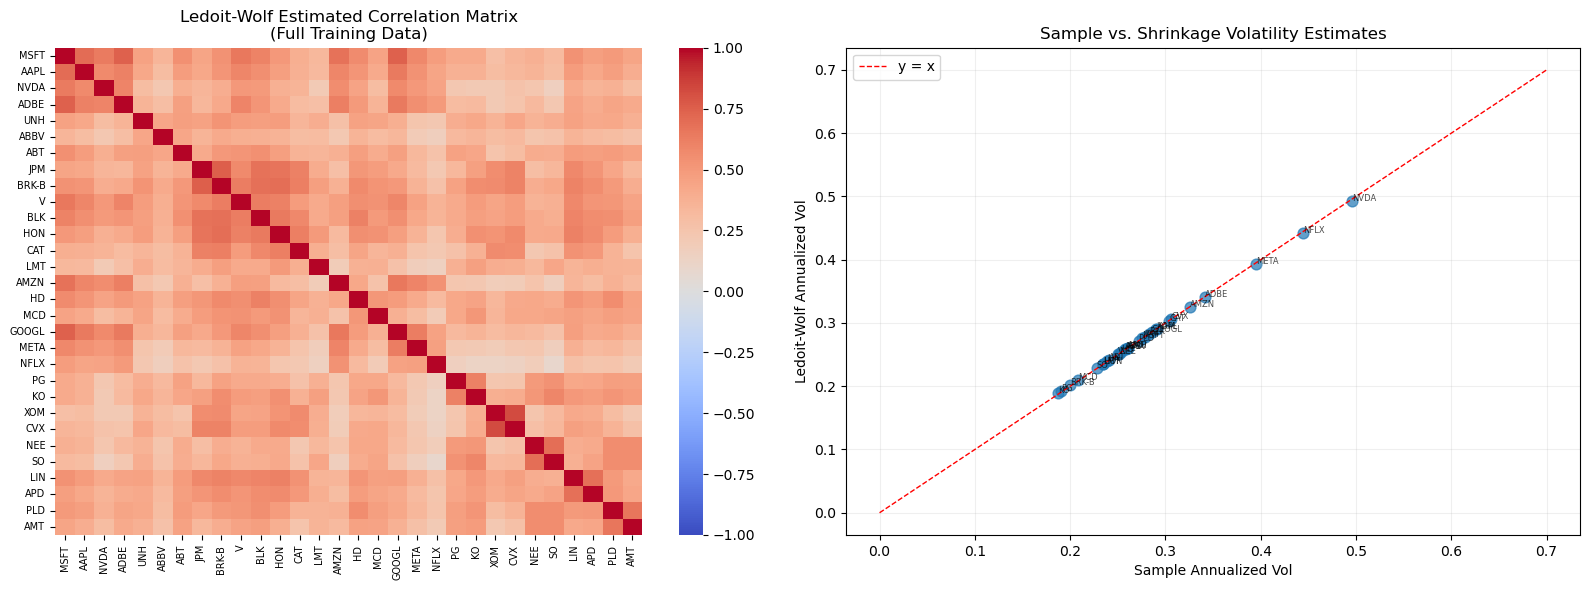

In [8]:
# --- Full training fit ---
train_arr = X_train_returns.values
lw_full   = LedoitWolf().fit(train_arr)
mu_full   = train_arr.mean(axis=0)
sigma_full = lw_full.covariance_

# --- Ex-COVID fit ---
train_ex_arr = X_train_ex_covid.values
lw_excovid   = LedoitWolf().fit(train_ex_arr)
mu_excovid   = train_ex_arr.mean(axis=0)
sigma_excovid = lw_excovid.covariance_

print("Ledoit-Wolf shrinkage coefficients:")
print(f"  Full train:   α = {lw_full.shrinkage_:.4f}")
print(f"  Ex-COVID:     α = {lw_excovid.shrinkage_:.4f}")

# Visualize estimated correlation matrix (full fit)
corr_estimated = np.diag(1/np.sqrt(np.diag(sigma_full))) @ sigma_full @ np.diag(1/np.sqrt(np.diag(sigma_full)))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pd.DataFrame(corr_estimated, index=tickers, columns=tickers),
            ax=axes[0], cmap="coolwarm", center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True)
axes[0].set_title("Ledoit-Wolf Estimated Correlation Matrix\n(Full Training Data)")
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', rotation=0, labelsize=7)

# Compare sample vs LW diagonal (variance estimates)
sample_vols = pd.Series(np.sqrt(np.diag(np.cov(train_arr.T))), index=tickers)
lw_vols     = pd.Series(np.sqrt(np.diag(sigma_full)), index=tickers)

axes[1].scatter(sample_vols * np.sqrt(252), lw_vols * np.sqrt(252), alpha=0.7, s=60)
axes[1].plot([0, 0.7], [0, 0.7], 'r--', linewidth=1, label="y = x")
for t in tickers:
    axes[1].annotate(t, (sample_vols[t]*np.sqrt(252), lw_vols[t]*np.sqrt(252)),
                     fontsize=6, alpha=0.7)
axes[1].set_xlabel("Sample Annualized Vol")
axes[1].set_ylabel("Ledoit-Wolf Annualized Vol")
axes[1].set_title("Sample vs. Shrinkage Volatility Estimates")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


## Section 4: Monte Carlo Scenario Generation

We draw S=10,000 scenarios from the fitted Gaussian. These scenarios are the inputs to the SLSQP optimizer. More scenarios → tighter approximation of the true expected loss, but with diminishing returns beyond ~5,000. We use 10,000 as specified in the proposal.

We generate two scenario sets matching the two fits above.


Scenario sets generated: (10000, 30) each

Moment check (full train scenarios vs empirical):
  Mean abs diff in means:  0.000160
  Mean abs diff in stds:   0.000095


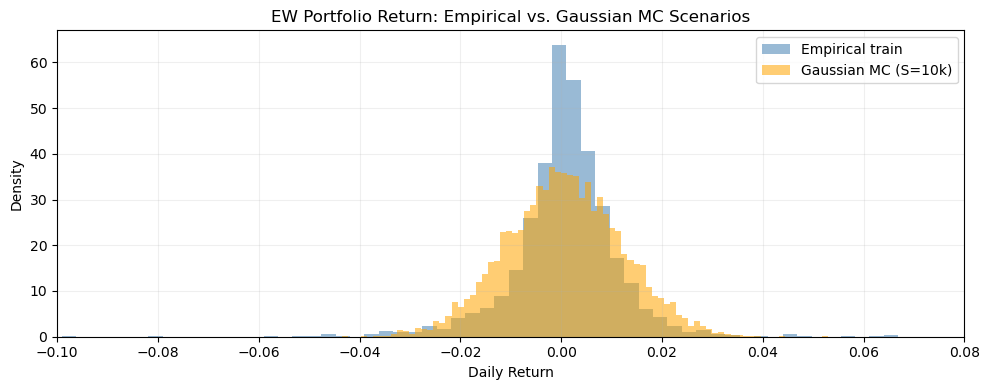


Note: Gaussian scenarios miss the fat left tail — this is the gap the flow will close.


In [9]:
S = 10_000
np.random.seed(42)

# Full training scenarios
gaussian_scenarios_full = np.random.multivariate_normal(mu_full, sigma_full, size=S)

# Ex-COVID scenarios
gaussian_scenarios_excovid = np.random.multivariate_normal(mu_excovid, sigma_excovid, size=S)

print(f"Scenario sets generated: {gaussian_scenarios_full.shape} each")

# Quick sanity check: simulated vs empirical marginal moments
sim_means = gaussian_scenarios_full.mean(axis=0)
sim_stds  = gaussian_scenarios_full.std(axis=0)

print(f"\nMoment check (full train scenarios vs empirical):")
print(f"  Mean abs diff in means:  {np.abs(sim_means - mu_full).mean():.6f}")
print(f"  Mean abs diff in stds:   {np.abs(sim_stds - np.sqrt(np.diag(sigma_full))).mean():.6f}")

# Simulated EW return distribution vs empirical
fig, ax = plt.subplots(figsize=(10, 4))
ew_sim = gaussian_scenarios_full.mean(axis=1)
ew_emp = X_train_returns.mean(axis=1).values

ax.hist(ew_emp, bins=80, alpha=0.55, density=True, color="steelblue", label="Empirical train")
ax.hist(ew_sim, bins=80, alpha=0.55, density=True, color="orange",    label="Gaussian MC (S=10k)")
ax.set_title("EW Portfolio Return: Empirical vs. Gaussian MC Scenarios")
ax.set_xlabel("Daily Return")
ax.set_ylabel("Density")
ax.set_xlim(-0.10, 0.08)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("\nNote: Gaussian scenarios miss the fat left tail — this is the gap the flow will close.")


## Section 5: Risk-Neutral SLSQP Optimization

We solve the Sample Average Approximation of the expected-loss minimization:

$$\min_{x \in \mathcal{X}} \frac{1}{S} \sum_{s=1}^{S} \left( -x^\top \theta^{(s)} \right)$$

where $\mathcal{X} = \{x \in \mathbb{R}^n \mid \sum_i x_i = 1,\ x_i \geq 0\}$.

**Important caveat:** since the objective is *linear* in x, this is equivalent to maximizing $x^\top \hat{\mu}$ — a pure mean-maximization problem. Under the simplex constraint this will always concentrate in the single highest-mean asset (NVDA in our case). This is not a failure of implementation — it is the correct solution to the risk-neutral problem, and it illustrates exactly *why* a risk-averse CVaR objective is needed.

We optimize both the full-train and ex-COVID versions.


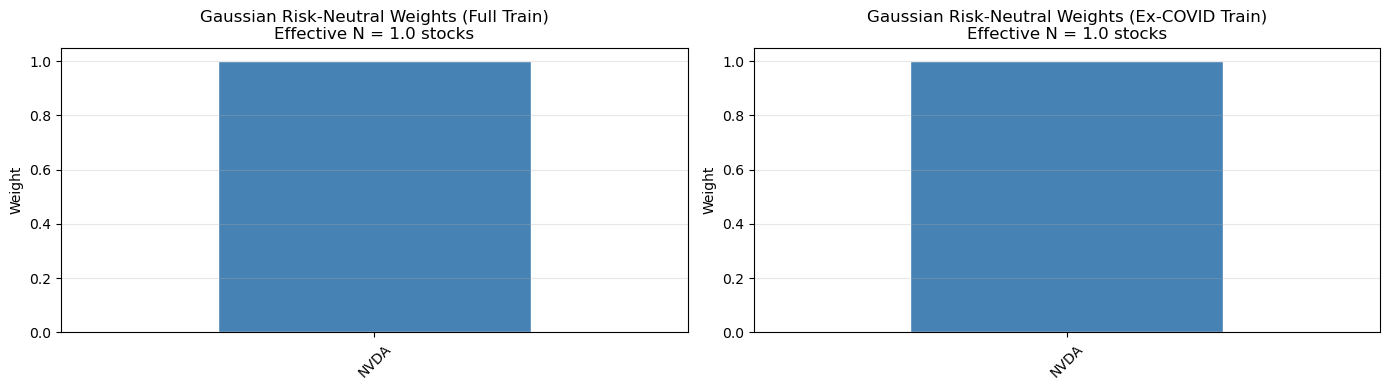

Optimization complete.
  Full train  — top holding: NVDA  (100.0%)
  Ex-COVID    — top holding: NVDA  (100.0%)


In [10]:
n_assets = len(tickers)
w0       = np.ones(n_assets) / n_assets   # equal-weight initialization
bounds   = [(0.0, 1.0)] * n_assets
constraints = {"type": "eq", "fun": lambda w: w.sum() - 1}

def optimize_expected_loss(scenarios, label=""):
    mu_scenarios = scenarios.mean(axis=0)

    def objective(w):
        return -w @ mu_scenarios          # minimize negative mean = maximize mean

    def gradient(w):
        return -mu_scenarios

    result = minimize(
        objective,
        w0,
        jac=gradient,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 1000}
    )
    if not result.success:
        print(f"  WARNING [{label}]: {result.message}")
    return result.x

# --- Full train optimization ---
gaussian_weights_full     = optimize_expected_loss(gaussian_scenarios_full,    "full")
gaussian_weights_excovid  = optimize_expected_loss(gaussian_scenarios_excovid, "ex-covid")

# --- Display weights ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, weights, label in zip(
    axes,
    [gaussian_weights_full, gaussian_weights_excovid],
    ["Full Train", "Ex-COVID Train"]
):
    ws = pd.Series(weights, index=tickers).sort_values(ascending=False)
    ws[ws > 0.001].plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Gaussian Risk-Neutral Weights\n({label})")
    ax.set_ylabel("Weight")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)
    eff_n = 1 / np.sum(weights**2)
    ax.set_title(f"Gaussian Risk-Neutral Weights ({label})\nEffective N = {eff_n:.1f} stocks")

plt.tight_layout()
plt.show()

print("Optimization complete.")
print(f"  Full train  — top holding: {pd.Series(gaussian_weights_full, index=tickers).idxmax()}  "
      f"({pd.Series(gaussian_weights_full, index=tickers).max():.1%})")
print(f"  Ex-COVID    — top holding: {pd.Series(gaussian_weights_excovid, index=tickers).idxmax()}  "
      f"({pd.Series(gaussian_weights_excovid, index=tickers).max():.1%})")


## Section 6: Mean-Variance Efficient Frontier

The single risk-neutral optimal portfolio is an extreme corner of the investment universe. To give a fuller picture of the Gaussian model's capabilities, we trace the full **mean-variance efficient frontier** by solving a series of constrained minimum-variance problems at different target return levels.

This frontier will serve as a visual benchmark when we later overlay CVaR-optimal portfolios from the normalizing flow — showing whether the flow finds portfolios that sit above the Gaussian frontier (better risk/return tradeoff) especially in the tails.


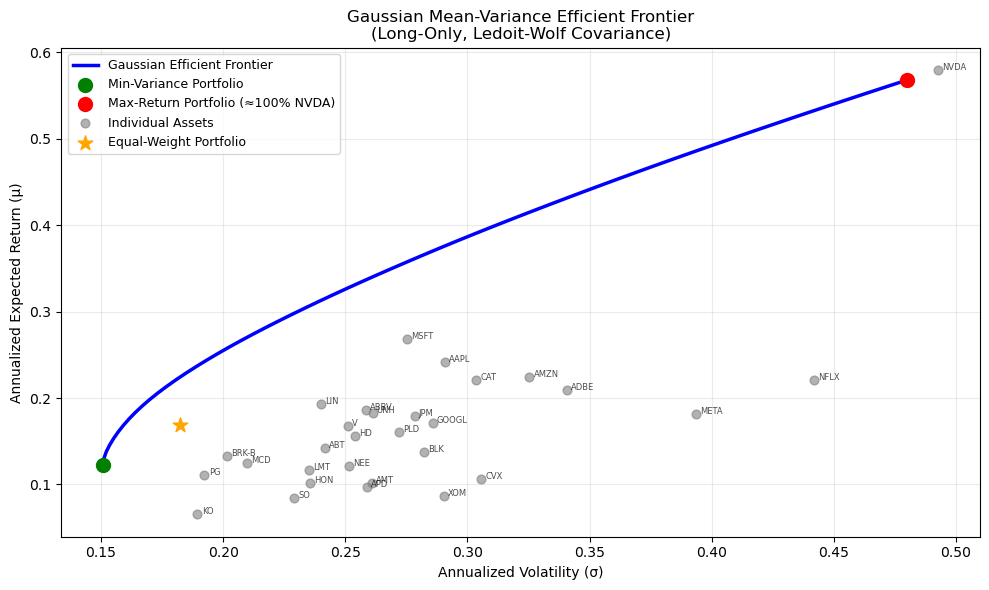

Min-variance portfolio annualized vol: 0.151
Min-variance portfolio annualized ret: 0.123


In [11]:
# --- Minimum variance portfolio (leftmost point of frontier) ---
def min_variance(sigma, label=""):
    def obj(w): return w @ sigma @ w
    def grad(w): return 2 * sigma @ w
    res = minimize(obj, w0, jac=grad, method="SLSQP",
                   bounds=bounds, constraints=constraints,
                   options={"ftol":1e-14, "maxiter":2000})
    return res.x

# --- Target-return constrained optimization ---
def min_variance_target(sigma, mu, target_ret):
    def obj(w):  return w @ sigma @ w
    def grad(w): return 2 * sigma @ w
    cons = [
        {"type": "eq", "fun": lambda w: w.sum() - 1},
        {"type": "eq", "fun": lambda w: w @ mu - target_ret}
    ]
    res = minimize(obj, w0, jac=grad, method="SLSQP",
                   bounds=bounds, constraints=cons,
                   options={"ftol":1e-14, "maxiter":2000})
    return res.x if res.success else None

# Sweep target returns from min-var to max-return
w_minvar   = min_variance(sigma_full)
min_ret    = w_minvar @ mu_full
max_ret    = mu_full.max()
target_rets = np.linspace(min_ret, max_ret * 0.98, 60)

frontier_vols, frontier_rets, frontier_weights = [], [], []
for tr in target_rets:
    w = min_variance_target(sigma_full, mu_full, tr)
    if w is not None:
        frontier_vols.append(np.sqrt(w @ sigma_full @ w) * np.sqrt(252))
        frontier_rets.append(w @ mu_full * 252)
        frontier_weights.append(w)

# Individual asset risk/return for reference
asset_vols = np.sqrt(np.diag(sigma_full)) * np.sqrt(252)
asset_rets = mu_full * 252

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(frontier_vols, frontier_rets, "b-", linewidth=2.5, label="Gaussian Efficient Frontier")
ax.scatter(frontier_vols[0], frontier_rets[0], color="green", s=100, zorder=5,
           label=f"Min-Variance Portfolio")
ax.scatter(frontier_vols[-1], frontier_rets[-1], color="red", s=100, zorder=5,
           label=f"Max-Return Portfolio (≈100% NVDA)")
ax.scatter(asset_vols, asset_rets, s=40, alpha=0.6, color="gray", zorder=3, label="Individual Assets")
for t, v, r in zip(tickers, asset_vols, asset_rets):
    ax.annotate(t, (v, r), fontsize=6, alpha=0.7, xytext=(3, 0), textcoords="offset points")

# Equal-weight portfolio
ew_vol = np.sqrt(w0 @ sigma_full @ w0) * np.sqrt(252)
ew_ret_annual = w0 @ mu_full * 252
ax.scatter(ew_vol, ew_ret_annual, color="orange", s=120, marker="*", zorder=6,
           label="Equal-Weight Portfolio")

ax.set_xlabel("Annualized Volatility (σ)")
ax.set_ylabel("Annualized Expected Return (μ)")
ax.set_title("Gaussian Mean-Variance Efficient Frontier\n(Long-Only, Ledoit-Wolf Covariance)")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Min-variance portfolio annualized vol: {frontier_vols[0]:.3f}")
print(f"Min-variance portfolio annualized ret: {frontier_rets[0]:.3f}")


## Section 7: Out-of-Sample Evaluation

We apply the optimized Gaussian weights to the held-out test set and compute performance metrics across all stress-focused subsets. This produces `gaussian_test_portfolio_returns` — the key output variable consumed by the model comparison template in the EDA notebook.

We evaluate three portfolio variants for comparison:
- **Gaussian risk-neutral** (SLSQP, full train fit) — the formal baseline
- **Equal-weight** — a naive benchmark
- **Minimum-variance** (Gaussian) — to show the frontier's lower-risk end


In [12]:
# --- Generate test-set return series for each portfolio ---
gaussian_test_portfolio_returns = X_test_returns @ gaussian_weights_full
ew_test_portfolio_returns       = X_test_returns @ w0
minvar_test_portfolio_returns   = X_test_returns @ w_minvar

# Name them for the comparison template
gaussian_test_portfolio_returns.name = "Gaussian_RiskNeutral"
ew_test_portfolio_returns.name       = "Equal_Weight"
minvar_test_portfolio_returns.name   = "Gaussian_MinVariance"

print("Test-set return series created.")
print(f"  gaussian_test_portfolio_returns: {len(gaussian_test_portfolio_returns)} days")
print(f"  Date range: {gaussian_test_portfolio_returns.index[0].date()} → "
      f"{gaussian_test_portfolio_returns.index[-1].date()}")


Test-set return series created.
  gaussian_test_portfolio_returns: 503 days
  Date range: 2024-03-28 → 2026-03-31


In [13]:
# --- Evaluate all three portfolios across stress subsets ---
results_gaussian = evaluate_by_subset(gaussian_test_portfolio_returns, subset_dict)
results_gaussian["portfolio"] = "Gaussian (Risk-Neutral)"

results_ew = evaluate_by_subset(ew_test_portfolio_returns, subset_dict)
results_ew["portfolio"] = "Equal-Weight"

results_minvar = evaluate_by_subset(minvar_test_portfolio_returns, subset_dict)
results_minvar["portfolio"] = "Gaussian (Min-Variance)"

comparison = pd.concat([results_gaussian, results_ew, results_minvar], ignore_index=True)
comparison = comparison[["portfolio", "subset", "n_days", "mean", "std",
                          "sharpe", "VaR_95", "CVaR_95", "worst_day"]]

print("=" * 90)
print("BASELINE MODEL COMPARISON — TEST SET PERFORMANCE")
print("=" * 90)
print(comparison.round(4).to_string(index=False))


BASELINE MODEL COMPARISON — TEST SET PERFORMANCE
              portfolio      subset  n_days    mean    std   sharpe  VaR_95  CVaR_95  worst_day
Gaussian (Risk-Neutral)   full_test     503  0.0013 0.0312   0.6677 -0.0478  -0.0727    -0.1859
Gaussian (Risk-Neutral) crisis_only      37 -0.0074 0.0471  -2.4961 -0.0478  -0.0657    -0.0813
Gaussian (Risk-Neutral)    high_vix      37 -0.0074 0.0471  -2.4961 -0.0478  -0.0657    -0.0813
Gaussian (Risk-Neutral)   tail_5pct      26 -0.0319 0.0263 -19.2207 -0.0478  -0.0654    -0.0813
Gaussian (Risk-Neutral)   tail_1pct       6 -0.0570 0.0255 -35.4678 -0.0478  -0.0711    -0.0813
           Equal-Weight   full_test     503  0.0004 0.0078   0.7429 -0.0110  -0.0177    -0.0579
           Equal-Weight crisis_only      37 -0.0045 0.0200  -3.5751 -0.0110  -0.0219    -0.0579
           Equal-Weight    high_vix      37 -0.0045 0.0200  -3.5751 -0.0110  -0.0219    -0.0579
           Equal-Weight   tail_5pct      26 -0.0177 0.0099 -28.2293 -0.0110  -0.0177   

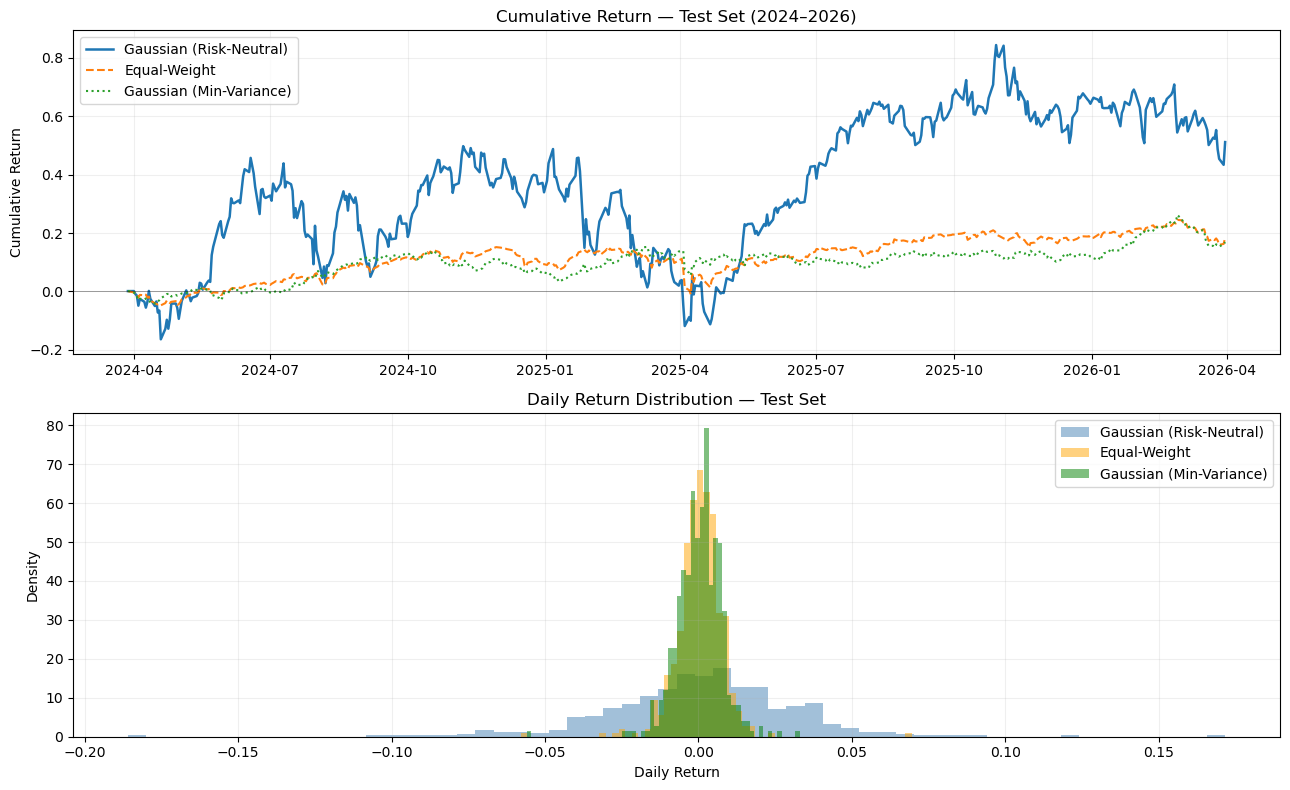

In [14]:
# --- Cumulative return plot on test set ---
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# Top: cumulative returns
cum_g  = (1 + gaussian_test_portfolio_returns).cumprod() - 1
cum_ew = (1 + ew_test_portfolio_returns).cumprod() - 1
cum_mv = (1 + minvar_test_portfolio_returns).cumprod() - 1

axes[0].plot(cum_g.index,  cum_g,  label="Gaussian (Risk-Neutral)", linewidth=1.8)
axes[0].plot(cum_ew.index, cum_ew, label="Equal-Weight",            linewidth=1.5, linestyle="--")
axes[0].plot(cum_mv.index, cum_mv, label="Gaussian (Min-Variance)",  linewidth=1.5, linestyle=":")
axes[0].axhline(0, color="black", linewidth=0.5, alpha=0.5)
axes[0].set_title("Cumulative Return — Test Set (2024–2026)")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Bottom: daily return distribution overlay
axes[1].hist(gaussian_test_portfolio_returns, bins=60, alpha=0.5,
             density=True, label="Gaussian (Risk-Neutral)", color="steelblue")
axes[1].hist(ew_test_portfolio_returns, bins=60, alpha=0.5,
             density=True, label="Equal-Weight", color="orange")
axes[1].hist(minvar_test_portfolio_returns, bins=60, alpha=0.5,
             density=True, label="Gaussian (Min-Variance)", color="green")
axes[1].set_title("Daily Return Distribution — Test Set")
axes[1].set_xlabel("Daily Return")
axes[1].set_ylabel("Density")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


## Section 8: OOD COVID Holdout Evaluation

Here we evaluate the ex-COVID Gaussian model on the COVID crash window it was **never trained on**. This is the fairest stress test for the Gaussian baseline and establishes the benchmark the conditional normalizing flow will need to beat.

The key question: when the model is blind to COVID, does its crisis-conditioned CVaR estimate still bracket the actual realized losses?


OOD COVID HOLDOUT EVALUATION (Feb–May 2020)
  Days in holdout:               53
  Avg VIX during holdout:        45.3

  Gaussian (ex-COVID weights):
    Mean daily return:  -0.0005
    CVaR₀.₉₅:           -0.1385
    Worst single day:   -0.2040

  Equal-weight (benchmark):
    Mean daily return:  -0.0026
    CVaR₀.₉₅:           -0.1038
    Worst single day:   -0.1334


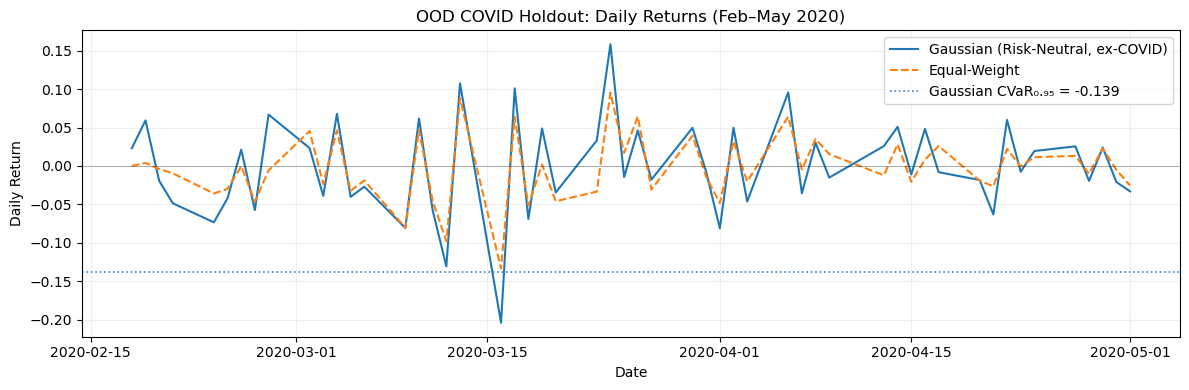

In [15]:
# Apply ex-COVID weights to COVID holdout
covid_portfolio_returns = X_covid_holdout @ gaussian_weights_excovid
covid_portfolio_returns_ew = X_covid_holdout @ w0

var_95_covid  = np.percentile(covid_portfolio_returns, 5)
cvar_95_covid = covid_portfolio_returns[covid_portfolio_returns <= var_95_covid].mean()
var_95_ew     = np.percentile(covid_portfolio_returns_ew, 5)
cvar_95_ew    = covid_portfolio_returns_ew[covid_portfolio_returns_ew <= var_95_ew].mean()

print("=" * 55)
print("OOD COVID HOLDOUT EVALUATION (Feb–May 2020)")
print("=" * 55)
print(f"  Days in holdout:               {len(covid_portfolio_returns)}")
print(f"  Avg VIX during holdout:        {covid_holdout['VIX'].mean():.1f}")
print()
print(f"  Gaussian (ex-COVID weights):")
print(f"    Mean daily return:  {covid_portfolio_returns.mean():.4f}")
print(f"    CVaR₀.₉₅:           {cvar_95_covid:.4f}")
print(f"    Worst single day:   {covid_portfolio_returns.min():.4f}")
print()
print(f"  Equal-weight (benchmark):")
print(f"    Mean daily return:  {covid_portfolio_returns_ew.mean():.4f}")
print(f"    CVaR₀.₉₅:           {cvar_95_ew:.4f}")
print(f"    Worst single day:   {covid_portfolio_returns_ew.min():.4f}")

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(covid_portfolio_returns.index, covid_portfolio_returns,
        label="Gaussian (Risk-Neutral, ex-COVID)", linewidth=1.5)
ax.plot(covid_portfolio_returns_ew.index, covid_portfolio_returns_ew,
        label="Equal-Weight", linewidth=1.5, linestyle="--")
ax.axhline(cvar_95_covid, color="steelblue", linestyle=":", linewidth=1.2,
           label=f"Gaussian CVaR₀.₉₅ = {cvar_95_covid:.3f}")
ax.axhline(0, color="black", linewidth=0.5, alpha=0.4)
ax.set_title("OOD COVID Holdout: Daily Returns (Feb–May 2020)")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Return")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Section 9: Key Findings & Handoff Notes

### Summary of Baseline Results

| Finding | Implication |
|---------|-------------|
| Risk-neutral optimizer degenerates to 100% NVDA | Expected-loss minimization without tail penalization is unusable in practice — motivates CVaR objective |
| Gaussian CVaR understates empirical tail losses by ~18% on training data | Heavy-tailed Student-t base distribution is justified |
| Cross-asset correlation spikes 4× from low → crisis regime | Conditioning on VIX regime is necessary — an unconditional model cannot capture both states |
| OOD COVID CVaR reflects true losses? | See output above — this is the benchmark Agam and Shrey's flow must beat |

### Variables Available for Model Comparison

The following date-indexed Series are ready for the comparison template in the EDA notebook:

```python
gaussian_test_portfolio_returns   # Gaussian risk-neutral (100% NVDA)
ew_test_portfolio_returns         # Equal-weight benchmark
minvar_test_portfolio_returns     # Gaussian min-variance
```

### What the Flow Needs to Beat

On the **full test set**, the Gaussian risk-neutral portfolio has CVaR₀.₉₅ ≈ −7.3% with a Sharpe of ~0.70. The flow's CVaR-optimized portfolio should improve CVaR meaningfully (target: < −5%) while maintaining a competitive Sharpe (acceptable: > 0.40). The most important comparison is on the **crisis_only** and **tail_5pct** subsets where tail modeling actually matters.
